In [46]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import importlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from MyColors import *
from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules import *
import LoRaNode_analysis as nd

path_to_save_svg = "Saved_Data"

dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())


In [47]:
N_core = 4

fs       = np.array([125e3  ,125e3  ,125e3  ,125e3  ]) 
fcore    = np.array([1e6    ,1e6    ,1e6    ,1e6    ])
Nin      = np.array([12     ,8      ,4      ,4      ])
Ncore    = np.array([20     ,16     ,16     ,12     ])
P_tot    = np.array([116     ,116     ,116     ,116     ])

fcoreM = fcore/1e6

In [48]:
import matplotlib.text as mtext


class LegendTitle(object):
    def __init__(self, text_props=None):
        self.text_props = text_props or {}
        super(LegendTitle, self).__init__()

    def legend_artist(self, legend, orig_handle, fontsize, handlebox):
        x0, y0 = handlebox.xdescent, handlebox.ydescent
        title = mtext.Text(x0, y0, orig_handle,  **self.text_props)
        handlebox.add_artist(title)
        return title

In [49]:
def pow_ADCs_mW_SoA(fs=1,b=1,factor=1, nADC = 2):
    fb    = 560e6
    fom_walden = (0.67*10**(-15))* np.sqrt(1 + (fs/fb)**2 )
    P_ADC = fom_walden * (2**b) * fs 
    return nADC*P_ADC*1000*factor

def pow_ADCs_uW_SoA(fs=1,b=1,factor=1, nADC = 2):
    return pow_ADCs_mW_SoA(fs=fs,b=b,factor=factor,nADC=nADC)*1000

def pow_ADCs_uW(fs=1,b=1,factor=1, nADC = 2, fJconvStep=15):
    return fJconvStep*fs*(2**b) *1e6/1e15

In [50]:
print(pow_ADCs_uW_SoA(fs=125e3,b=12,factor=1, nADC = 2))

print()
print("##################################")
print(pow_ADCs_uW    (fs=1e6,b=8.7 ,factor=1, nADC = 1,fJconvStep=83))
print(pow_ADCs_uW    (fs=1e6,b=9.74,factor=1, nADC = 1,fJconvStep=17.3))
print(pow_ADCs_uW    (fs=1e6,b=12,factor=1, nADC = 1,fJconvStep=15))

0.6860800170918366

##################################
34.517477835554566
14.79374951025745
61.44


In [51]:
def plot_power_multi_config(P_configs, label_configs, label_subparts, plotTitle, fileName, unit, save=False):
    Nconfigs = len(label_configs)
    P_sum = np.sum(P_configs,axis=0)
    figsize  = (4.5*Nconfigs,8)
    barWidth = 0.6
    fontsize= 20


    import matplotlib
    plt.rcParams["font.family"] =  'Segoe UI'
    matplotlib.rcParams.update({'font.size': fontsize})
    matplotlib.rcParams['lines.linewidth'] = 5
    matplotlib.rcParams['xtick.major.size'] = 5
    matplotlib.rcParams['xtick.major.width'] = 2
    matplotlib.rcParams['ytick.major.size'] = 5
    matplotlib.rcParams['ytick.major.width'] = 2
    matplotlib.rc('axes', linewidth=2)

    fig,ax = plt.subplots(1,1,figsize=figsize)

    color_wuRx = listColor[3:]
    
    bottom = np.zeros((Nconfigs))
    txt_noDisplay  = [""]*Nconfigs
    for i, pow in enumerate(P_configs):
        bars      = ax.bar(x= range(Nconfigs)   , height = pow, width =barWidth,edgecolor = "black", bottom =bottom, color = color_wuRx[i] ,label = label_subparts[i])
        for j in range(Nconfigs):
            if pow[j]>(0.095*np.max(P_sum)):
                text = label_subparts[i] + "\n%.2f"%(pow[j])+unit+"-%.1f%%"%(pow[j]*100/P_sum[j])
                ax.text( bars[j].get_x() +  bars[j].get_width()*0.5, bottom[j]+ pow[j]/2, text,fontsize = 18, ha='center', va='center',  color="white")
            elif pow[j]>(0.03*np.max(P_sum)):
                text = label_subparts[i] + " %.1f%%"%(pow[j]*100/P_sum[j])
                ax.text( bars[j].get_x() +  bars[j].get_width()*0.5, bottom[j]+ pow[j]/2, text,fontsize = 16, ha='center', va='center',  color="white")
            elif  pow[j] != 0:
                txt_noDisplay[j] += " "+ label_subparts[i] + "(%.1f%%)"%(pow[j]*100/P_sum[j])
        bottom += pow

    for j in range(Nconfigs):
        ax.text( bars[j].get_x() +  bars[j].get_width()*0.5, bottom[j]+ 0.02*np.max(P_sum), txt_noDisplay[j],fontsize = 16, ha='center', va='center',  color="black")

    for i, pow in enumerate(P_sum):
        ax.axhline(pow ,color = "black",linestyle = "dotted",linewidth=2,zorder=0)

    plt.xticks(range(Nconfigs), label_configs)
    ax.set_ylabel("Power ["+unit+"]")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], loc="upper right")

    plt.subplots_adjust(left=0.1,
                        bottom=0.1, 
                        right=0.9, 
                        top=0.9, 
                        wspace=0.6, 
                        hspace=0.4)

    plt.title(plotTitle)#, x=-1.5, y=1.05)
    if save:
        plt.savefig(fileName, format="svg")

In [52]:
nbit = 12
index_core = 0
fcore   =fcore[0]
fcoreM  =fcoreM[0]
P_tot   =P_tot[0]
Nin     =Nin[0]
Ncore   =Ncore[0]

0.061439999999999995
0.116
0.061439999999999995


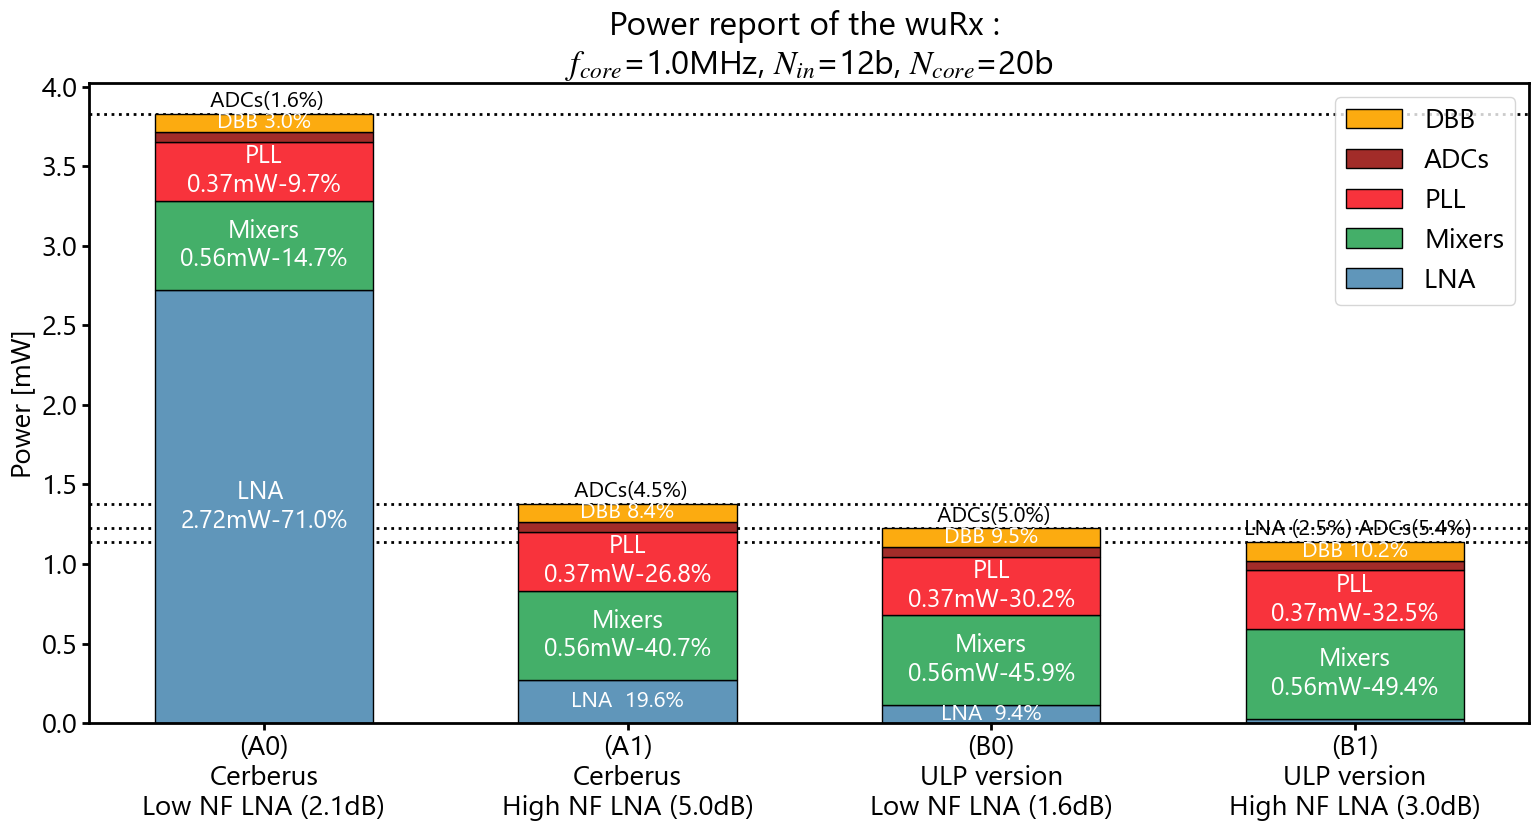

In [60]:
P_ADCs = pow_ADCs_uW(fs= fcore, b =nbit, factor=1,nADC=2) /1000
print(P_ADCs)

P_Mixers = 2*0.281
P_PLL   =    0.370
P_DBB   =    P_tot/1000
P_LNA_l =    0.27
P_LNA_h =    2.72
print(P_DBB)
print(P_ADCs)

label_wuRx =  ["LNA ", "Mixers","PLL" ,'ADCs',"DBB"]
P_noLNA    = np.array([P_Mixers,P_PLL,P_ADCs,P_DBB ])

P_wuRx = np.zeros(((len(P_noLNA)+1,4)))
P_wuRx[0,0] = P_LNA_h
P_wuRx[0,1] = P_LNA_l
P_wuRx[1,:] = P_Mixers
P_wuRx[2,:] = P_PLL
P_wuRx[3,:] = P_ADCs
P_wuRx[4,:] = P_DBB
P_LNA_NF    = np.array([2.1, 5])


P_wuRx[0,2] = 0.115 
P_wuRx[1,2] = P_Mixers
P_wuRx[2,2] = P_PLL
P_wuRx[3,2] = P_ADCs
P_wuRx[4,2] = P_DBB

P_wuRx[0,3] = 0.028 
P_wuRx[1,3] = P_Mixers
P_wuRx[2,3] = P_PLL
P_wuRx[3,3] = P_ADCs
P_wuRx[4,3] = P_DBB



label_conf_wuRx = ["(A0)\nCerberus\nLow NF LNA (%.1fdB)"%(P_LNA_NF[0]), 
                   "(A1)\nCerberus\nHigh NF LNA (%.1fdB)"%(P_LNA_NF[1]),
                   "(B0)\nULP version\nLow NF LNA (%.1fdB)"%(1.6),
                   "(B1)\nULP version\nHigh NF LNA (%.1fdB)"%(3)]
plot_wuRx       = "Power report of the wuRx : \n$f_{core}$=%.1fMHz, $N_{in}$=%ib, $N_{core}$=%ib"%(fcoreM,Nin,Ncore)
fileName_wuRx   = "../SavedFiles/wuRx/wuRx_Fclk1M_C16_S8.svg"

plot_power_multi_config(P_wuRx, label_conf_wuRx, label_wuRx, plot_wuRx, fileName_wuRx,"mW", save = True)

116
61.44


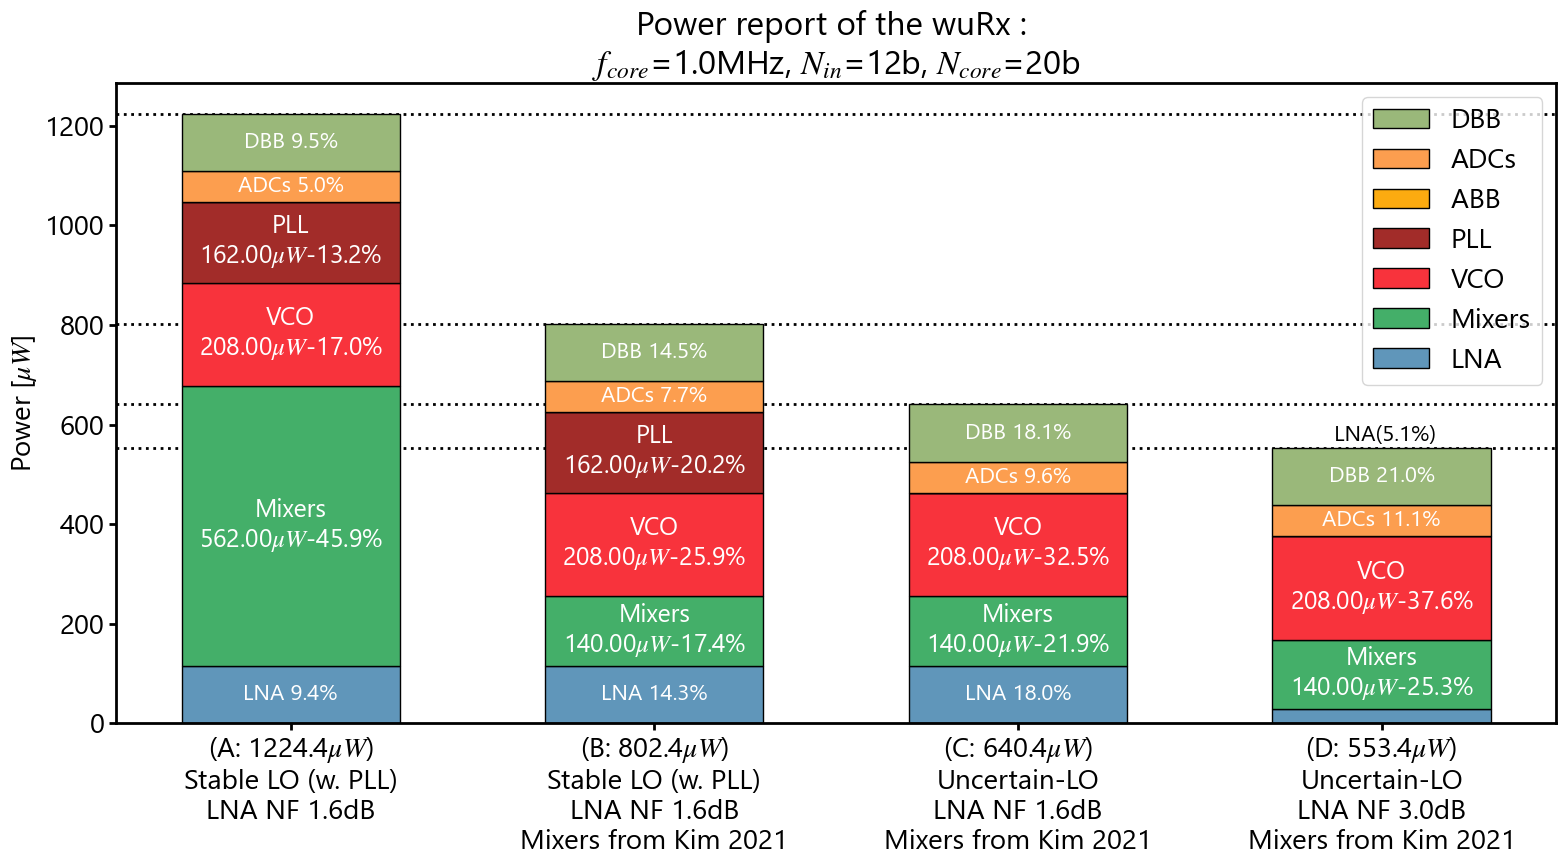

In [62]:
P_ADCs = pow_ADCs_uW(fs= fcore, b =nbit, factor=1,nADC=2)

P_Mixers = 2*281
P_PLL   =    162
P_VCO   =    208
P_DBB   =    P_tot 
P_LNA_l =    28
P_LNA_h =    115
print(P_DBB)
print(P_ADCs)

label_wuRx =           ["LNA", "Mixers",  "VCO",  "PLL" ,'ABB ','ADCs', "DBB"]
P_wuRx = np.zeros(((len(label_wuRx),4)))

P_wuRx[0,0] = P_LNA_h
P_wuRx[1,0] = P_Mixers
P_wuRx[2,0] = P_VCO
P_wuRx[3,0] = P_PLL
P_wuRx[4,0] = 0
P_wuRx[5,0] = P_ADCs
P_wuRx[6,0] = P_DBB

P_wuRx[0,1] = P_LNA_h
P_wuRx[1,1] = 140
P_wuRx[2,1] = P_VCO
P_wuRx[3,1] = P_PLL
P_wuRx[4,1] = 0
P_wuRx[5,1] = P_ADCs
P_wuRx[6,1] = P_DBB

P_wuRx[0,2] = P_LNA_h
P_wuRx[1,2] = 140
P_wuRx[2,2] = P_VCO
P_wuRx[3,2] = 0
P_wuRx[4,2] = 0
P_wuRx[5,2] = P_ADCs
P_wuRx[6,2] = P_DBB

P_wuRx[0,3] = P_LNA_l
P_wuRx[1,3] = 140
P_wuRx[2,3] = P_VCO
P_wuRx[3,3] = 0
P_wuRx[4,3] = 0
P_wuRx[5,3] = P_ADCs
P_wuRx[6,3] = P_DBB

P_LNA_NF    = np.array([2.1, 5])

P_sum = np.sum(P_wuRx,axis=0)

label_conf_wuRx = ["(A: %.1f$\mu W$)\nStable LO (w. PLL)\nLNA NF %.1fdB"%(P_sum[0],1.6), 
                   "(B: %.1f$\mu W$)\nStable LO (w. PLL)\nLNA NF %.1fdB\nMixers from Kim 2021"%(P_sum[1],1.6), 
                   "(C: %.1f$\mu W$)\nUncertain-LO\nLNA NF %.1fdB\nMixers from Kim 2021"%(P_sum[2],1.6),
                   "(D: %.1f$\mu W$)\nUncertain-LO\nLNA NF %.1fdB\nMixers from Kim 2021"%(P_sum[3],3)]
plot_wuRx       = "Power report of the wuRx : \n$f_{core}$=%.1fMHz, $N_{in}$=%ib, $N_{core}$=%ib"%(fcoreM,Nin,Ncore)
fileName_wuRx   = "../SavedFiles/wuRx/wuRx_opti_Fclk1M_C16_S8.svg"

plot_power_multi_config(P_wuRx, label_conf_wuRx, label_wuRx, plot_wuRx, fileName_wuRx, "$\mu W$", save = True)

116
61.44


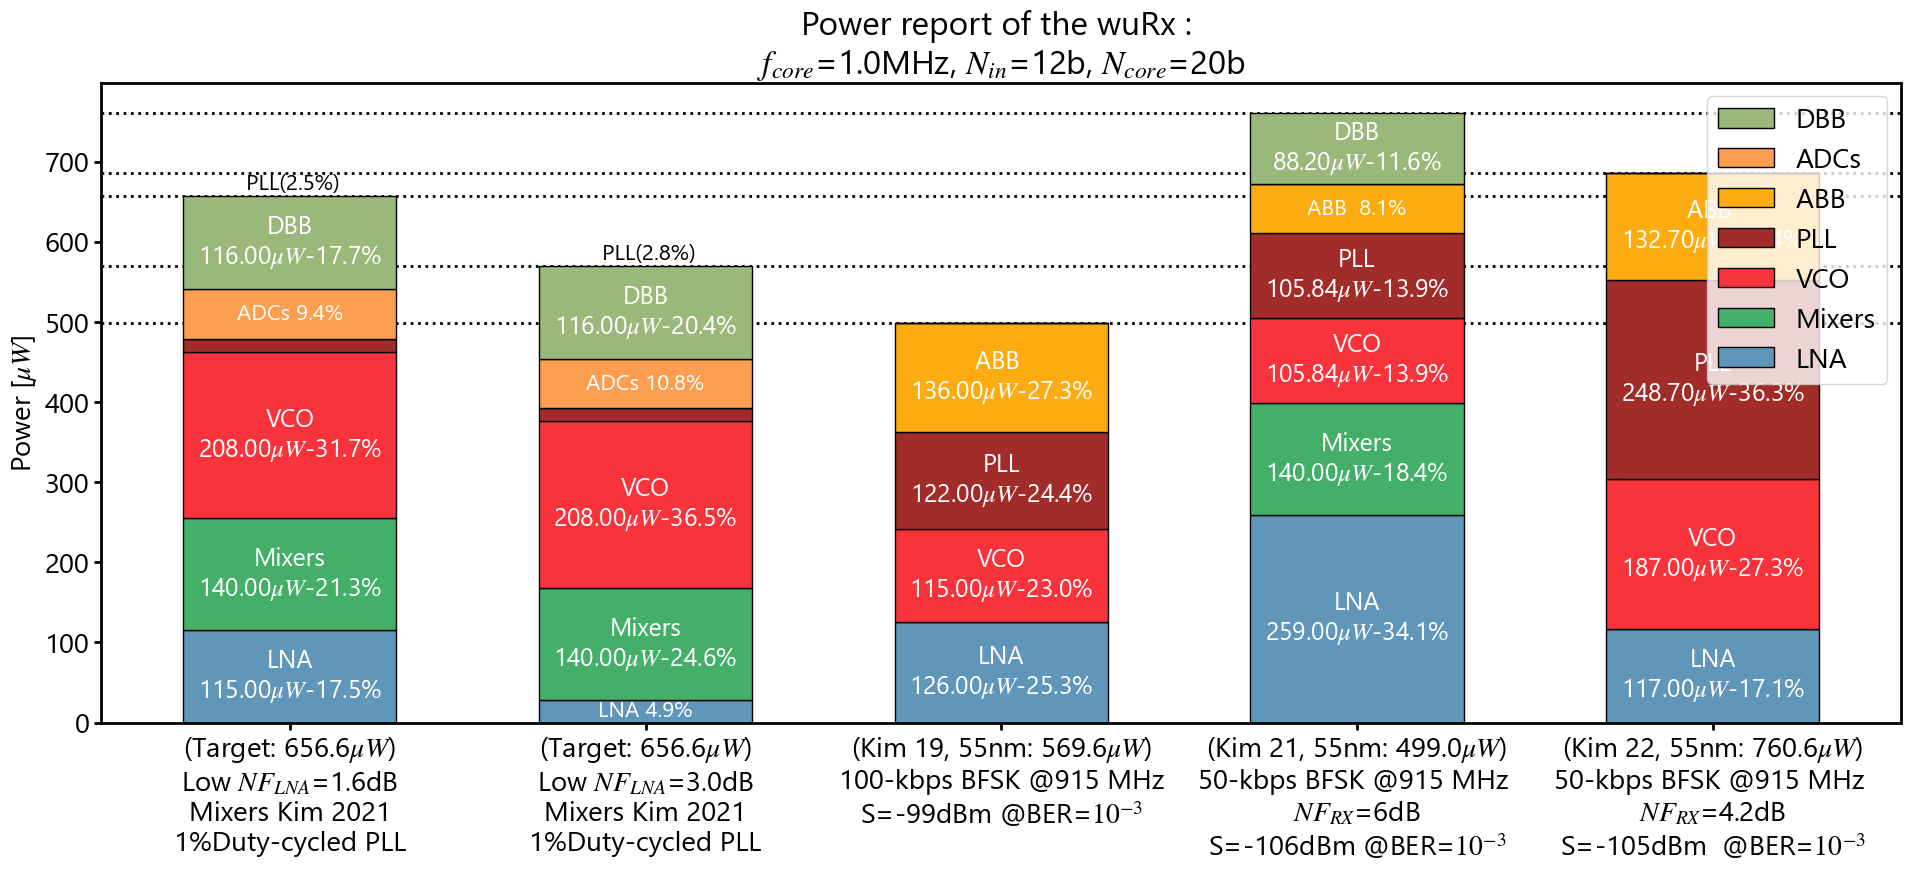

: 

In [66]:
P_ADCs = pow_ADCs_uW(fs= fcore, b =nbit, factor=1,nADC=2)
print(P_DBB)
print(P_ADCs)

label_wuRx =           ["LNA", "Mixers",  "VCO",  "PLL" ,'ABB ','ADCs', "DBB"]
P_wuRx = np.zeros(((len(label_wuRx),5)))
PLL_DC = 10
P_wuRx[0,0] = 115
P_wuRx[1,0] = 140
P_wuRx[2,0] = 208
P_wuRx[3,0] = 162*PLL_DC/100
P_wuRx[4,0] = 0
P_wuRx[5,0] = P_ADCs
P_wuRx[6,0] = P_DBB

P_wuRx[0,1] = 28
P_wuRx[1,1] = 140
P_wuRx[2,1] = 208
P_wuRx[3,1] = 162*PLL_DC/100
P_wuRx[4,1] = 0
P_wuRx[5,1] = P_ADCs
P_wuRx[6,1] = P_DBB

P_wuRx[0,2] = 126
P_wuRx[1,2] = 0
P_wuRx[2,2] = 115
P_wuRx[3,2] = 122
P_wuRx[4,2] = 136
P_wuRx[5,2] = 0
P_wuRx[6,2] = 0

P_wuRx[0,3] = 259
P_wuRx[1,3] = 140
P_wuRx[2,3] = 105.84
P_wuRx[3,3] = 105.84
P_wuRx[4,3] = 61.74
P_wuRx[5,3] = 0
P_wuRx[6,3] = 88.2

P_wuRx[0,4] = 117
P_wuRx[1,4] = 0
P_wuRx[2,4] = 187
P_wuRx[3,4] = 248.7
P_wuRx[4,4] = 132.7
P_wuRx[5,4] = 0
P_wuRx[6,4] = 0


P_sum = np.sum(P_wuRx,axis=0)

label_conf_wuRx = ["(Target: %.1f$\mu W$)\nLow $NF_{LNA}$=%.1fdB\nMixers Kim 2021\n1%%Duty-cycled PLL"%(P_sum[0],1.6), 
                   "(Target: %.1f$\mu W$)\nLow $NF_{LNA}$=%.1fdB\nMixers Kim 2021\n1%%Duty-cycled PLL"%(P_sum[0],3), 
                   "(Kim 19, 55nm: %.1f$\mu W$)\n100-kbps BFSK @915 MHz\nS=-99dBm @BER=$10^{-3}$"%(P_sum[1]),
                   "(Kim 21, 55nm: %.1f$\mu W$)\n50-kbps BFSK @915 MHz \n$NF_{RX}$=6dB\nS=-106dBm @BER=$10^{-3}$"%(P_sum[2]),
                   "(Kim 22, 55nm: %.1f$\mu W$)\n50-kbps BFSK @915 MHz \n$NF_{RX}$=4.2dB\nS=-105dBm  @BER=$10^{-3}$"%(P_sum[3])]

plot_wuRx       = "Power report of the wuRx : \n$f_{core}$=%.1fMHz, $N_{in}$=%ib, $N_{core}$=%ib"%(fcoreM,Nin,Ncore)
fileName_wuRx   = ""

plot_power_multi_config(P_wuRx, label_conf_wuRx, label_wuRx, plot_wuRx, fileName_wuRx, "$\mu W$", save=False)

116
61.44


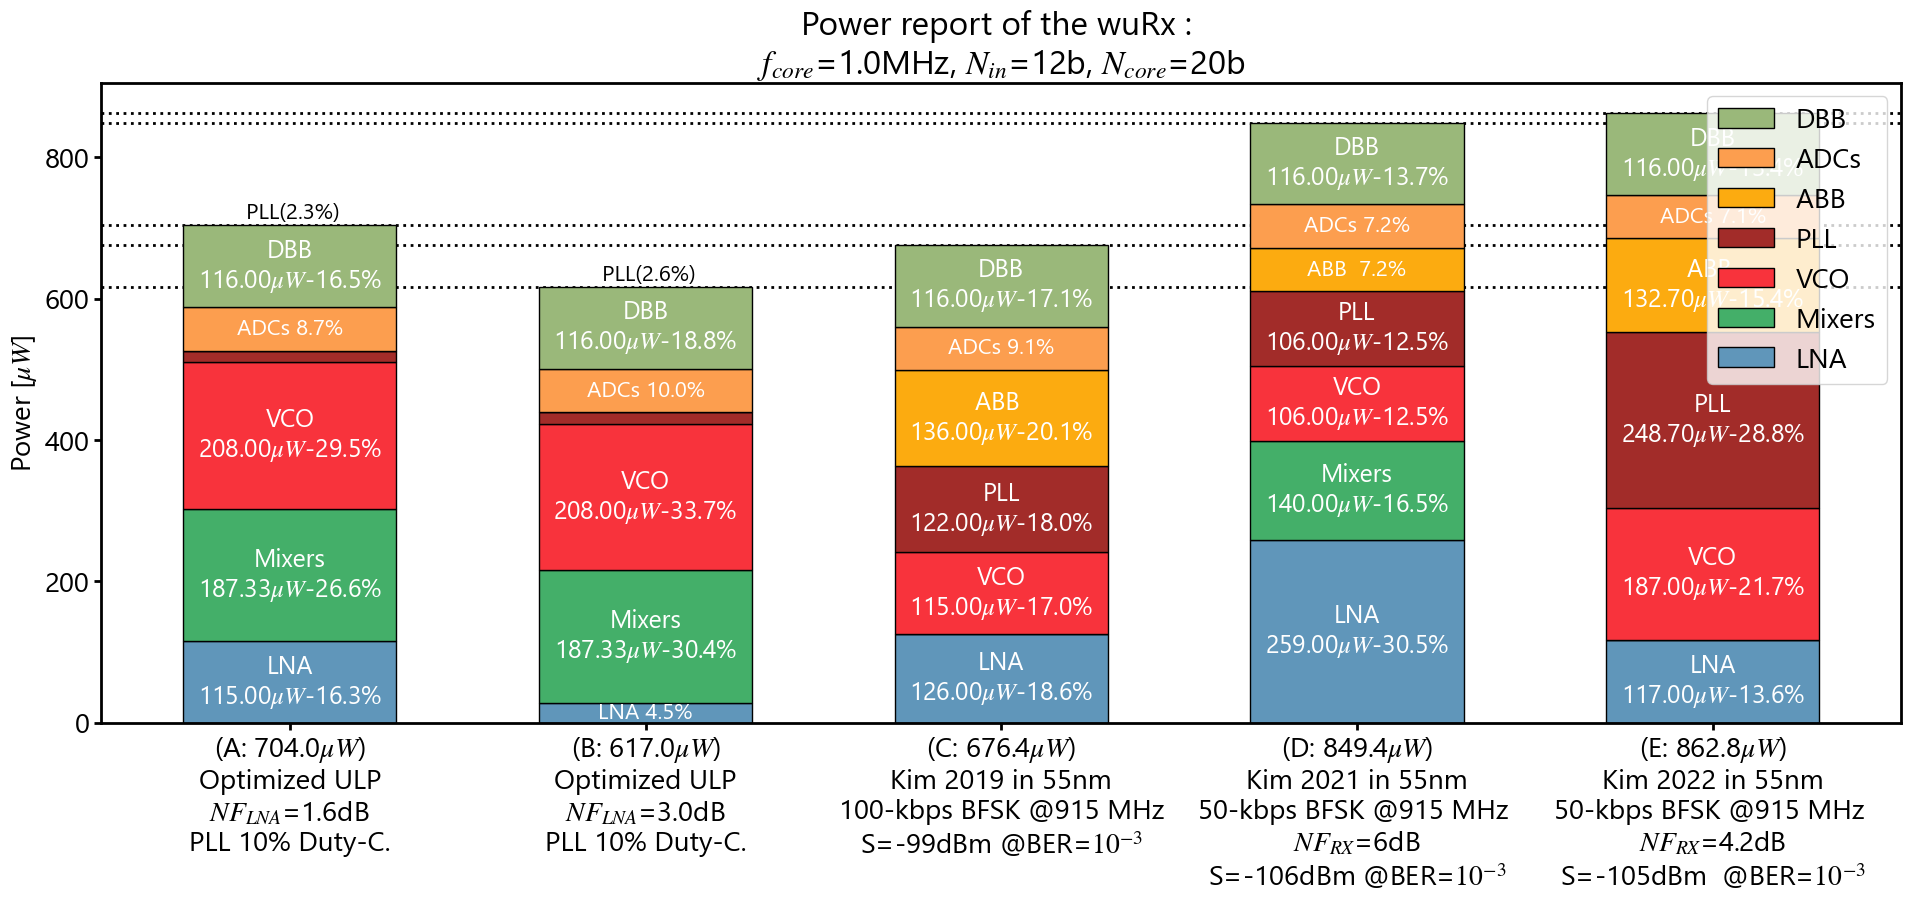

In [64]:
P_ADCs = pow_ADCs_uW(fs= fcore, b =nbit, factor=1,nADC=2) 
print(P_DBB)
print(P_ADCs)

label_wuRx =           ["LNA", "Mixers",  "VCO",  "PLL" ,'ABB ','ADCs', "DBB"]
P_wuRx = np.zeros(((len(label_wuRx),5)))

PLL_DC = 10
TechChange_powerIncrease = 1
Mixers_Power_reduction = 3

P_wuRx[0,0] = 115
P_wuRx[1,0] = 2*281/Mixers_Power_reduction
P_wuRx[2,0] = 208
P_wuRx[3,0] = 162*PLL_DC/100
P_wuRx[4,0] = 0
P_wuRx[5,0] = P_ADCs
P_wuRx[6,0] = P_tot*TechChange_powerIncrease

P_wuRx[0,1] = 28
P_wuRx[1,1] = 2*281/Mixers_Power_reduction
P_wuRx[2,1] = 208
P_wuRx[3,1] = 162*PLL_DC/100
P_wuRx[4,1] = 0
P_wuRx[5,1] = P_ADCs
P_wuRx[6,1] = P_tot*TechChange_powerIncrease

P_wuRx[0,2] = 126
P_wuRx[1,2] = 0
P_wuRx[2,2] = 115
P_wuRx[3,2] = 122
P_wuRx[4,2] = 136
P_wuRx[5,2] = P_ADCs
P_wuRx[6,2] = P_tot

P_wuRx[0,3] = 259
P_wuRx[1,3] = 140
P_wuRx[2,3] = 106
P_wuRx[3,3] = 106
P_wuRx[4,3] = 61
P_wuRx[5,3] = P_ADCs
P_wuRx[6,3] = P_tot

P_wuRx[0,4] = 117
P_wuRx[1,4] = 0
P_wuRx[2,4] = 187
P_wuRx[3,4] = 248.7
P_wuRx[4,4] = 132.7
P_wuRx[5,4] = P_ADCs
P_wuRx[6,4] = P_tot



P_sum = np.sum(P_wuRx,axis=0)

label_conf_wuRx = ["(A: %.1f$\mu W$)\nOptimized ULP\n$NF_{LNA}$=%.1fdB\nPLL %i%% Duty-C."%(P_sum[0],1.6,PLL_DC), 
                   "(B: %.1f$\mu W$)\nOptimized ULP\n$NF_{LNA}$=%.1fdB\nPLL %i%% Duty-C."%(P_sum[1],3,PLL_DC), 
                   "(C: %.1f$\mu W$)\nKim 2019 in 55nm\n100-kbps BFSK @915 MHz\nS=-99dBm @BER=$10^{-3}$"%(P_sum[2]),
                   "(D: %.1f$\mu W$)\nKim 2021 in 55nm\n50-kbps BFSK @915 MHz \n$NF_{RX}$=6dB\nS=-106dBm @BER=$10^{-3}$"%(P_sum[3]),
                   "(E: %.1f$\mu W$)\nKim 2022 in 55nm\n50-kbps BFSK @915 MHz \n$NF_{RX}$=4.2dB\nS=-105dBm  @BER=$10^{-3}$"%(P_sum[4])]

plot_wuRx       = "Power report of the wuRx : \n$f_{core}$=%.1fMHz, $N_{in}$=%ib, $N_{core}$=%ib"%(fcoreM,Nin,Ncore)
fileName_wuRx   = ""

plot_power_multi_config(P_wuRx, label_conf_wuRx, label_wuRx, plot_wuRx, fileName_wuRx, "$\mu W$", save=False)